### RNN (Recurent Neural Network) : 단기메모리
- 순서가 중요, 이전사건이 다음사건에 영향을 미치는 구조
- 순서가 중요한 데이터를 --> 시계열
- 자연어, 주식, 날씨, 실시간 센서데이터
- 단점 : 장기메모리에 약함
- 개선 : LSTM(RNN에 비해서 오래 기억하지만 그래도 희석됨)
- 트랜스포머 : 집중해야할것 즉 기억해야할 중요내용만 저장(어텐션), 마스킹
### MLP
- 모든입력이 독립적, 자연어는 순서가 중요(단어의 순서)

In [1]:
from nltk.corpus import movie_reviews
reviews = [movie_reviews.raw(fileid) for fileid in movie_reviews.fileids()]
categories = [movie_reviews.categories(fileid)[0] for fileid in movie_reviews.fileids()]

In [2]:
len(reviews), len(reviews[0]), set(categories)

(2000, 4043, {'neg', 'pos'})

In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
np.random.seed(42)
tf.random.set_seed(42)

In [4]:
# 사용할 단어수
max_words = 10000
tokenizer = Tokenizer(num_words=max_words, oov_token='UNK')  #빈도가 높은 10000개의 단어를 선택
tokenizer.fit_on_texts(reviews)  # 단어 인덱스 구축
x = tokenizer.texts_to_sequences(reviews)  # 인덱스를 기반으로 원래 문장을 숫자로 변환(벡터화, 개별적으로 즉 길이는 서로 다름)

In [5]:
len(x[0]), len(x[1]), x[0][:10]

(710, 240, [98, 77, 949, 4622, 131, 6, 3, 2016, 789, 3764])

In [6]:
# 학습을 위해서는 모든 문장의 길이가 같아야 함 - > 패딩  짧으면 채우고 길면 자르고
from tensorflow.keras.preprocessing.sequence import pad_sequences
maxlen = 500
x = pad_sequences(x,maxlen=maxlen,truncating='pre' )  # 앞을 자름

In [7]:
len(x[0]), len(x[1]), x[0][:10]

(500,
 500,
 array([ 911,  115,   53,   21, 5278,    5, 1387,  172,    9,  633],
       dtype=int32))

In [8]:
label_dict = {'pos' : 1, 'neg' : 0}
y = np.array([label_dict[c] for c in categories])
y[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [9]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42,test_size=0.2)

In [10]:
x_train.shape

(1600, 500)

In [20]:
# 일반신경망으로 분리
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten,Dense,Embedding, Dropout

model = Sequential([
    Embedding(max_words,32,input_length=maxlen),    # 1600, 500 --> 1600, 500, 32
    Dropout(0.5),
    Flatten(),
    Dense(1,activation='sigmoid')  # 확률 분포
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
history = model.fit(x_train, y_train, epochs=10,validation_split=0.2)

Epoch 1/10


c:\Users\Playdata\miniconda3\envs\torch_env\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - acc: 0.5352 - loss: 0.6921 - val_acc: 0.5219 - val_loss: 0.6952
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - acc: 0.8852 - loss: 0.6214 - val_acc: 0.5437 - val_loss: 0.6926
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.9594 - loss: 0.5341 - val_acc: 0.5500 - val_loss: 0.6866
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - acc: 0.9844 - loss: 0.4134 - val_acc: 0.6000 - val_loss: 0.6792
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - acc: 0.9914 - loss: 0.2900 - val_acc: 0.6219 - val_loss: 0.6687
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - acc: 0.9969 - loss: 0.1901 - val_acc: 0.6250 - val_loss: 0.6573
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - acc: 0.9992 - loss: 0.1246 - val_acc: 0.6313 - val_loss: 0.6499
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - acc: 0.9992 - loss: 0.0856 - val_acc: 0.6375 - val_loss: 0.6467
Epoch 9/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - acc: 0.9992 - loss: 0.

dict_keys(['acc', 'loss', 'val_acc', 'val_loss'])


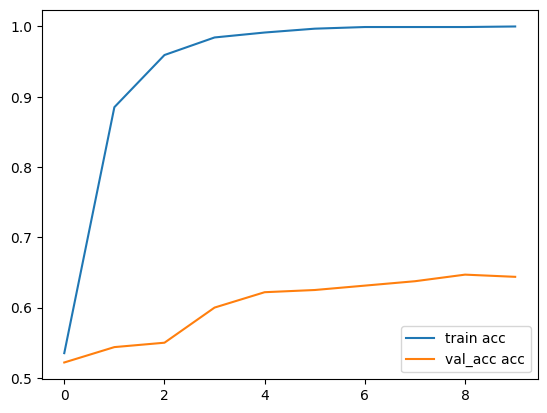

In [21]:
import matplotlib.pyplot as plt
print(history.history.keys())
plt.plot(history.history['acc'], label = 'train acc')
plt.plot(history.history['val_acc'], label = 'val_acc acc')
plt.legend()
plt.show()

In [24]:
model.evaluate(x_test,y_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.6350 - loss: 0.6382


[0.6382490396499634, 0.6349999904632568]

In [32]:
from tensorflow.keras.layers import SimpleRNN
model = Sequential([
    Embedding(max_words,32,input_length=maxlen),    # 1600, 500 --> 1600, 500, 32
    SimpleRNN(32),    # 1600, 32   단순선형모델에 사용되는 Flatten 대신    
    Dropout(0.5),
    Dense(64,activation='relu'),  # 확률 분포
    Dropout(0.5),
    Dense(1,activation='sigmoid')  # 확률 분포
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
history = model.fit(x_train, y_train, epochs=10,validation_split=0.2)
model.evaluate(x_test,y_test)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - acc: 0.4945 - loss: 0.7015 - val_acc: 0.5156 - val_loss: 0.6938
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - acc: 0.5586 - loss: 0.6876 - val_acc: 0.4563 - val_loss: 0.6979
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - acc: 0.6055 - loss: 0.6650 - val_acc: 0.4812 - val_loss: 0.7008
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - acc: 0.7312 - loss: 0.6000 - val_acc: 0.4844 - val_loss: 0.7119
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - acc: 0.7906 - loss: 0.5048 - val_acc: 0.5188 - val_loss: 0.7500
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - acc: 0.9312 - loss: 0.2815 - val_acc: 0.4781 - val_loss: 0.9515
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - acc: 0.9719 - loss: 0.1266 - val_acc: 0.4625 - val_loss: 1.0265
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - acc: 0.9914 - loss: 0.0643 - val_acc: 0.4781 - val_loss: 1.2514
Epoch 9/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - acc: 0.996

[1.2834477424621582, 0.5400000214576721]

In [37]:
np.astype(model.predict(x_test).reshape(-1,) > 0.5, int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


array([0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1,

In [41]:
sum(np.astype(model.predict(x_test).reshape(-1,) > 0.5, int) == y_test) / len(y_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


np.float64(0.54)